In [24]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [1]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy
import matplotlib
import scipy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

from datetime import datetime, timedelta
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import netCDF4
import string

import numpy as np
import xarray as xr
from scipy.spatial import cKDTree
from datetime import timedelta
import gsw
import ArcTools as Atools

# TEMP

In [2]:
ds_all = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_3/temp_common_full.nc',decode_times=False)
ds_all

<xarray.Dataset>
Dimensions:          (profile: 307937, depth: 187)
Coordinates:
  * profile          (profile) int64 0 2 3 4 5 ... 320213 320214 320215 320216
  * depth            (depth) float64 1.0 3.0 5.0 ... 5.3e+03 5.4e+03 5.5e+03
Data variables:
    longitude        (profile) float64 ...
    latitude         (profile) float64 ...
    time             (profile) float64 ...
    source           (profile) object ...
    dataset_index    (profile) float64 ...
    is_duplicate     (profile) float64 ...
    temperature      (profile, depth) float64 ...
    sum_temperature  (profile) float64 ...
    sum_depth        (profile) float64 ...
    nb_depth         (profile) float64 ...
    temperature_QC   (profile, depth) float64 ...
Attributes:
    title:        ARGO temperature profiles
    source:       ARGO
    featureType:  profile
    Comments:     ARGO temperature profiles interpolated on ISAS vertical lev...

# Load ISAS

In [3]:
# path = "/data0/user/aprigent/ISAS/ISAS23_DMFD_m*_TEMP.nc"
# files = sorted(glob.glob(path))
# temp_isas_01 = xr.open_dataset(files[0])
# # Open and concatenate along a new dimension
# ds_ISAS_tmp = xr.concat(
#     [xr.open_dataset(f).TEMP.isel(t=0) for f in files],
#     dim="month"
# )


# ds_ISAS = xr.Dataset({'temp':(['month','depth','latitude','longitude'],ds_ISAS_tmp.values)},
                     
#                      coords={'month': np.arange(1,13,1),
#                              'depth': temp_isas_01.depth.values,
#                              'latitude': temp_isas_01.latitude.values,
#                              'longitude': temp_isas_01.longitude.values})
# ds_ISAS.to_netcdf('/data0/user/aprigent/ISAS/ISAS23_TEMP_clim.nc')
ds_ISAS = xr.open_dataset('/data0/user/aprigent/ISAS/ISAS23_TEMP_clim.nc')

In [4]:
ds_all_anom = ds_all.copy()
del ds_all

In [5]:

ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles = ds_masks.interp(
    lon=ds_all_anom.longitude % 360,
    lat=ds_all_anom.latitude,
    method="nearest"
)


In [6]:

profiles_anom_amerasian = ds_all_anom.where(
    basin_at_profiles.BARENTS == 1,
    drop=True
)
# Only profiles after 01/01/2005
# profiles_anom_amerasian = profiles_anom_amerasian.where(profiles_anom_amerasian.time >= 731947, drop=True)
profiles_anom_amerasian = profiles_anom_amerasian


In [7]:
times = profiles_anom_amerasian.time.values
# convert time to datetime
dt_list = [datetime.fromordinal(int(t)) for t in times]
profile_temp = np.array(profiles_anom_amerasian.temperature_QC.values)


# Find the nearest ISAS point to each profile
    

In [8]:
lons = xr.DataArray(profiles_anom_amerasian.longitude.values, dims="profile")
lats = xr.DataArray(profiles_anom_amerasian.latitude.values, dims="profile")
months = xr.DataArray([dt.month for dt in dt_list], dims="profile")
    

In [9]:
   # Interpolate basin mask to profile positions
temp_isas_profiles = ds_ISAS.temp.interp(
    longitude=lons,
    latitude=lats
)
del ds_ISAS
temp_isas_profiles_new = temp_isas_profiles.sel(month=months)
# del temp_isas_profiles
temp_anom = profile_temp - temp_isas_profiles_new.values

profiles_anom_amerasian['temperature_QC_anom'] = (('profile','depth'),temp_anom)
del profile_temp,temp_anom

In [10]:
profiles_anom_amerasian['source'] = profiles_anom_amerasian['source'].astype(str)

In [11]:
profiles_anom_amerasian.to_netcdf('/data0/user/aprigent/PROCESSED/level_4/temp_anomalies_relative_ISAS_barents_full.nc')

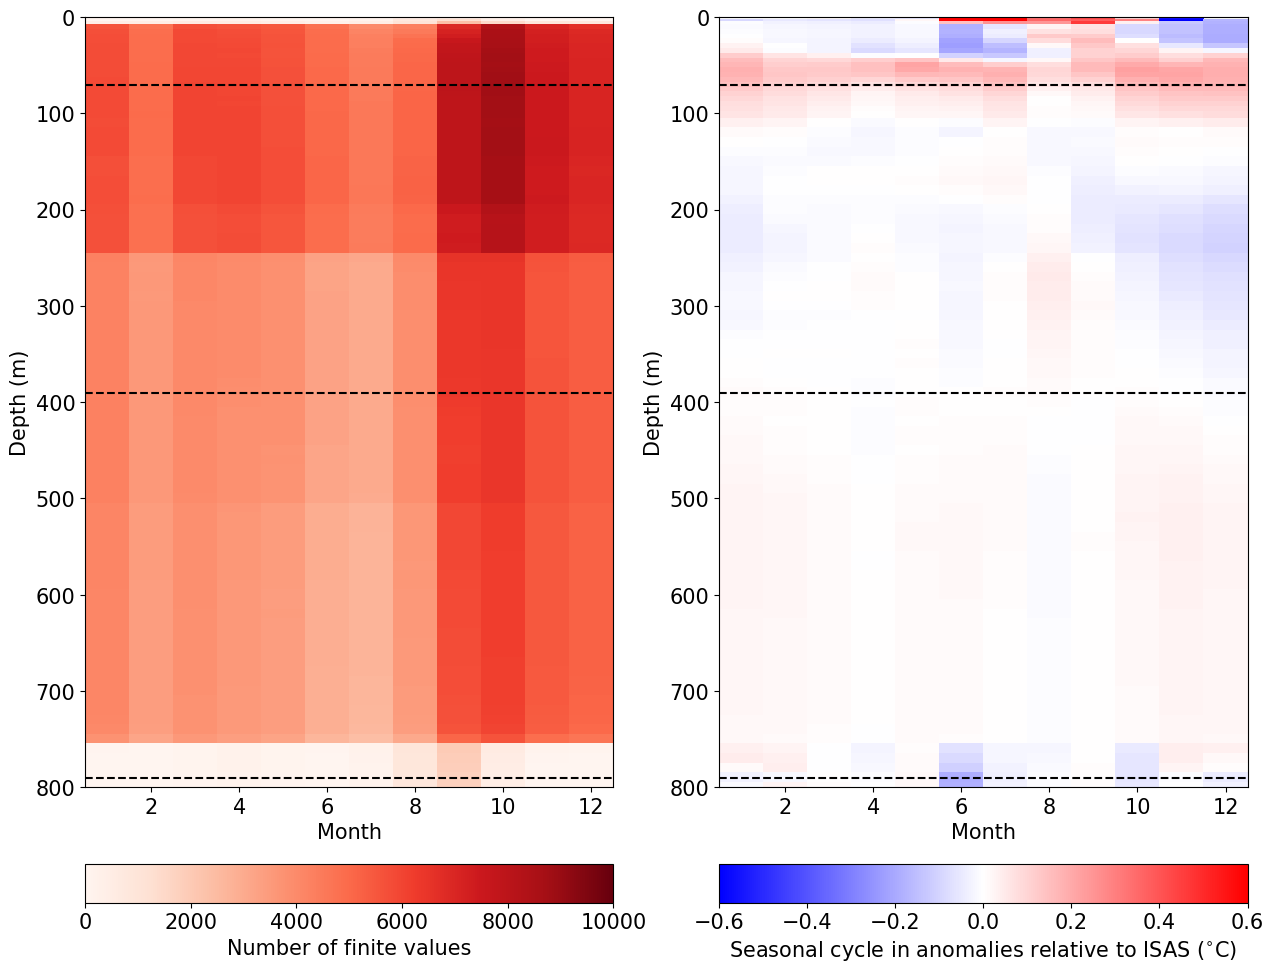

In [13]:
f,ax = plt.subplots(1,2,figsize=[15,10])
ftz=15
ax=ax.ravel()
cax0 = inset_axes(ax[0],
                   width="100%",  # width = 5% of parent_bbox width
                   height="5%",  # height : 50%
                   loc='lower left',
                   bbox_to_anchor=(0, -0.15, 1, 1),
                   bbox_transform=ax[0].transAxes,
                   borderpad=0,
                   )
cax1 = inset_axes(ax[1],
                   width="100%",  # width = 5% of parent_bbox width
                   height="5%",  # height : 50%
                   loc='lower left',
                   bbox_to_anchor=(0, -0.15, 1, 1),
                   bbox_transform=ax[1].transAxes,
                   borderpad=0,
                   )



p0=ax[0].pcolor(np.arange(1,13,1),
          profiles_anom_amerasian.depth.values,
          profiles_anom_amerasian.temperature_QC_anom.groupby(months).count('profile').values.T,cmap=plt.cm.Reds,vmin=0,vmax =10000)

ax[0].invert_yaxis()
ax[0].set_ylim([800,0])
ax[0].set_ylabel('Depth (m)',fontsize=ftz)
ax[0].tick_params(labelsize=ftz)
ax[0].set_xlabel('Month',fontsize=ftz)
ax[0].axhline(profiles_anom_amerasian.depth.values[15],color='black',linestyle='--')
ax[0].axhline(profiles_anom_amerasian.depth.values[50],color='black',linestyle='--')
ax[0].axhline(profiles_anom_amerasian.depth.values[90],color='black',linestyle='--')
cbar = plt.colorbar(p0,cax0,orientation='horizontal')
cbar.ax.tick_params(labelsize=ftz)
cbar.set_label('Number of finite values', size=ftz)






p1=ax[1].pcolor(np.arange(1,13,1),
          profiles_anom_amerasian.depth.values,
          profiles_anom_amerasian.temperature_QC_anom.groupby(months).mean('profile').values.T,vmin=-0.6,vmax=0.6,cmap=plt.cm.bwr)
ax[1].axhline(profiles_anom_amerasian.depth.values[15],color='black',linestyle='--')
ax[1].axhline(profiles_anom_amerasian.depth.values[50],color='black',linestyle='--')
ax[1].axhline(profiles_anom_amerasian.depth.values[90],color='black',linestyle='--')
ax[1].invert_yaxis()
ax[1].set_ylim([800,0])
ax[1].set_ylabel('Depth (m)',fontsize=ftz)
ax[1].tick_params(labelsize=ftz)
ax[1].set_xlabel('Month',fontsize=ftz)

cbar = plt.colorbar(p1,cax1,orientation='horizontal')
cbar.ax.tick_params(labelsize=ftz)
cbar.set_label('Seasonal cycle in anomalies relative to ISAS ($^{\circ}$C)', size=ftz)




   
plt.savefig('/home/aprigent/Documents/Projects/Analysis_obs/figures/fig_seasonal_cycle_TEMP_anomalies_amerasian.png',bbox_inches='tight',dpi=300)

# Seasonal means

In [61]:
# ---------------------------------------------------------
# Load dataset containing temperature anomalies
# ---------------------------------------------------------
ds_all = xr.open_dataset(
    '/data0/user/aprigent/PROCESSED/level_3/temp_anomalies_relative_ISAS_amerasian.nc',
    
)


profiles_basin_JFM = ds_all.where(
    ds_all.time.dt.month.isin([1, 2, 3]),
    drop=True
)


profiles_basin_AMJ = ds_all.where(
    ds_all.time.dt.month.isin([4, 5, 6]),
    drop=True
)


profiles_basin_JAS = ds_all.where(
    ds_all.time.dt.month.isin([7, 8, 9]),
    drop=True
)


profiles_basin_OND = ds_all.where(
    ds_all.time.dt.month.isin([10, 11, 12]),
    drop=True
)
# print(profiles_basin)
# profiles_basin["time"] = [t.toordinal() for t in profiles_basin.time.values]
# print(profiles_basin)

In [62]:
import pandas as pd

time_ordinal = [pd.Timestamp(t).toordinal() for t in profiles_basin_JFM.time.values]
profiles_basin_JFM.time.values = time_ordinal
profiles_basin_JFM['source'] = profiles_basin_JFM['source'].astype(str)
profiles_basin_JFM.to_netcdf('/data0/user/aprigent/PROCESSED/level_3/temp_anomalies_relative_ISAS_amerasian_JFM.nc')

In [68]:
time_ordinal = [pd.Timestamp(t).toordinal() for t in profiles_basin_AMJ.time.values]
profiles_basin_AMJ.time.values = time_ordinal
profiles_basin_AMJ['source'] = profiles_basin_AMJ['source'].astype(str)
profiles_basin_AMJ.to_netcdf('/data0/user/aprigent/PROCESSED/level_3/temp_anomalies_relative_ISAS_amerasian_AMJ.nc')

In [70]:
time_ordinal = [pd.Timestamp(t).toordinal() for t in profiles_basin_JAS.time.values]
profiles_basin_JAS.time.values = time_ordinal
profiles_basin_JAS['source'] = profiles_basin_JAS['source'].astype(str)
profiles_basin_JAS.to_netcdf('/data0/user/aprigent/PROCESSED/level_3/temp_anomalies_relative_ISAS_amerasian_JAS.nc')

In [71]:
time_ordinal = [pd.Timestamp(t).toordinal() for t in profiles_basin_OND.time.values]
profiles_basin_OND.time.values = time_ordinal
profiles_basin_OND['source'] = profiles_basin_OND['source'].astype(str)
profiles_basin_OND.to_netcdf('/data0/user/aprigent/PROCESSED/level_3/temp_anomalies_relative_ISAS_amerasian_OND.nc')